In [20]:
# Se necessário, instale antes de rodar:
# !pip install lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler


In [21]:
inicio = time.perf_counter()

In [22]:
# Reprodutibilidade
SEED = 123

In [23]:
df = pd.read_csv("final_dataset.csv")

In [24]:
# Agrupa chuva intensa na classe Rain
df["precipitation"] = df["precipitation"].replace("Extreme rain", "Rain")

X = df.drop(columns=["precipitation"])
y = df["precipitation"]

# Ordem usada na matriz de confusão:
# cm[0, 0] = Rain predito como Rain
# cm[0, 1] = Rain predito como No rain
# cm[1, 0] = No rain predito como Rain
# cm[1, 1] = No rain predito como No rain
labels = ["Rain", "No rain"]

y.value_counts()

precipitation
No rain    431380
Rain        37431
Name: count, dtype: int64

In [25]:
def criar_modelo_lightgbm(seed=SEED):
    """Cria o pipeline do LightGBM.

    O undersampling fica dentro da validação cruzada, evitando balancear
    antes da separação treino/teste de cada fold.
    """
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("modelo", LGBMClassifier(
            objective="binary",
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            verbosity=-1

            # Hiperparâmetros opcionais para controlar overfitting e tempo:
            # n_estimators=100,
            # learning_rate=0.1,
            # max_depth=5,
            # num_leaves=15,
            # min_child_samples=50,
            # reg_alpha=0.1,
            # reg_lambda=0.1
        ))
    ])


def metricas_da_matriz(cm):
    """Calcula métricas considerando a ordem: labels = ['Rain', 'No rain']."""
    VP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    VN = cm[1, 1]

    acuracia = (VP + VN) / cm.sum()
    sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    especificidade = VN / (VN + FP) if (VN + FP) > 0 else np.nan

    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade
    }


In [26]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cm_total = np.zeros((2, 2), dtype=int)
matrizes_folds = {}
resultados = []

y_test_total = []
y_prob_total = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    modelo_lgbm = criar_modelo_lightgbm()
    modelo_lgbm.fit(X_train_fold, y_train_fold)

    y_pred_fold = modelo_lgbm.predict(X_test_fold)

    cm_fold = confusion_matrix(
        y_test_fold,
        y_pred_fold,
        labels=labels
    )

    cm_total += cm_fold
    matrizes_folds[f"Fold {fold}"] = cm_fold

    # Probabilidade prevista para a classe Rain
    indice_rain = list(modelo_lgbm.named_steps["modelo"].classes_).index("Rain")
    y_prob_fold = modelo_lgbm.predict_proba(X_test_fold)[:, indice_rain]

    y_test_bin_fold = (y_test_fold == "Rain").astype(int)

    metricas = metricas_da_matriz(cm_fold)
    metricas["AUC"] = roc_auc_score(y_test_bin_fold, y_prob_fold)

    for metrica, valor in metricas.items():
        resultados.append({
            "Fold": fold,
            "Métrica": metrica,
            "Valor": valor
        })

    y_test_total.extend(y_test_bin_fold.to_numpy())
    y_prob_total.extend(y_prob_fold)

In [27]:
matriz_confusao_total = pd.DataFrame(
    cm_total,
    index=["Real Rain", "Real No rain"],
    columns=["Predito Rain", "Predito No rain"]
)

resultados_cv = pd.DataFrame(resultados)

tabela_cv = resultados_cv.pivot(
    index="Métrica",
    columns="Fold",
    values="Valor"
)

tabela_cv.columns = [f"Fold {col}" for col in tabela_cv.columns]
tabela_cv["Média"] = tabela_cv.mean(axis=1)
tabela_cv["DP"] = tabela_cv.std(axis=1)

display(matriz_confusao_total)
display(tabela_cv)

,Predito Rain,Predito No rain
Real Rain,28277,9154
Real No rain,118560,312820


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,DP
Métrica,,,,,,,
AUC,0.814160,0.818759,0.815944,0.816755,0.818571,0.816838,0.001713
Acurácia,0.726683,0.732109,0.726883,0.726691,0.725528,0.727579,0.002315
Especificidade,0.724512,0.730099,0.724837,0.723851,0.722507,0.725161,0.002595
Sensibilidade,0.751703,0.755277,0.750468,0.759418,0.760353,0.755443,0.003967


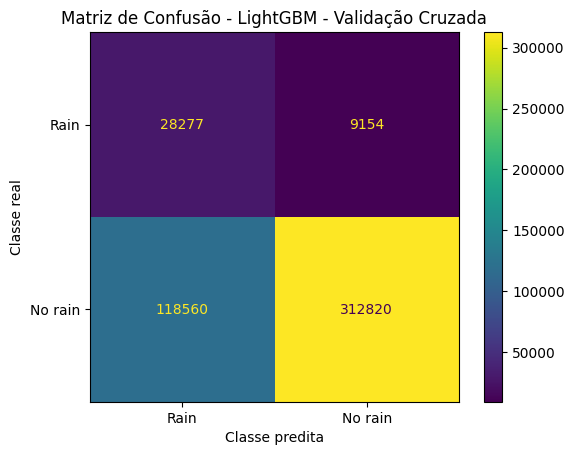

In [28]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_total.astype(int),
    display_labels=labels
).plot(values_format="d")

plt.title("Matriz de Confusão - LightGBM - Validação Cruzada")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")

plt.savefig("matriz_confusao_lightgbm.png", dpi=300, bbox_inches="tight")

plt.show()

AUC geral: 0.8167767189163102


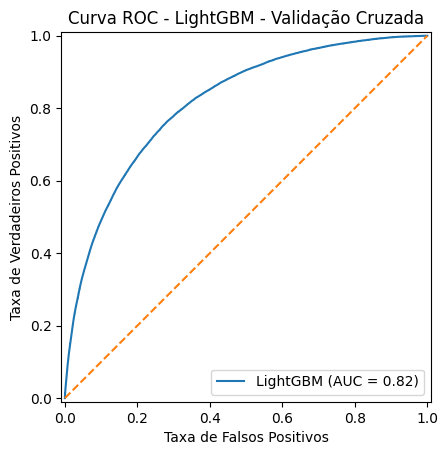

In [29]:
y_test_total = np.array(y_test_total)
y_prob_total = np.array(y_prob_total)

fpr, tpr, thresholds = roc_curve(y_test_total, y_prob_total)
auc = roc_auc_score(y_test_total, y_prob_total)

print("AUC geral:", auc)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc,
    estimator_name="LightGBM"
).plot()

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - LightGBM - Validação Cruzada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")

plt.savefig("curva_roc_lightgbm.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
fim = time.perf_counter()

tempo_total = fim - inicio

horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

print(f"Tempo total do experimento: {horas}h {minutos}min {segundos:.2f}s")

Tempo total do experimento: 0h 0min 13.77s
